Ahilan's Notes

For many tasks where a system can be well modeled/described by a set of mathematical equations, there is no need for ANNs (despite everyone wanting to apply them to everything). However, for systems where models are unknown, ANNs have been shown to be able to learn relationships and even be predictive.



1950’s, Hodgkin and Huxley came up with their now-famous model consisting of a set of coupled differential equations for Neurons


A simpler model that describes the firing of a neuron is the following: Imagine the ith neuron of our neural network has a set of input neurons, coupled to it by synapses, with weights 𝑤𝑖𝑗 for the jth input. Each of these input neurons has a firing rate 𝑥𝑗 quantifying how many action potentials they send per unit time. The input signal from one of these neurons is thus 𝑤𝑖𝑗𝑥𝑗. The total input signal received by neuron i is then 𝐼𝑖=Σ𝑤𝑖𝑗𝑥𝑗𝑗. To capture the nonlinear physics of the action potential, one models the firing of the receiving neuron as a nonlinear function of the total input signal: 𝑥𝑖=𝑓𝑖(𝐼𝑖). This could be a simple threshold function (e.g., a Heaviside function) or some sigmoid-type function (e.g., tanh or the logistic function) so that the output firing rate is bounded. The resulting dynamics of the network and what it can learn are primarily specified by the weights 𝑤𝑖𝑗.


They become ‘deep’ when there are many convolutional layers stacked on top of each other, hence the term ‘deep learning’.





Machine learning is a fancy way of saying, ‘fitting a high-dimensional model to data’. (It is slightly more than that, but that is the basic premise.) 

We have a set of inputs (there could be many such variables [called features]) and a set of observed outputs (this also could be many variables). We seek to fit some model (with many fittable parameters) to the data, and we would like it to generalize. This means that we don’t want it to overfit our data so that it does poorly on data it has never seen before. To minimize overfitting, the data is split into training, validation, and test sets. The test set is left out of the fitting process. The training and validation sets are used to ‘learn’ the parameters in the model. An iterative procedure is used to update the parameters in the model using the training data, and then the trained model is scored on the validation data. This process of training and scoring on the validation data is continued until the scores on the validation data consistently get worse.



One class of problems particularly well suited to neural nets is image classification. Given an image of an object that belongs to one of a set of categories, the goal is to predict which category the object belongs to. Our visual system is excellent at doing this by learning important patterns/features in images, starting from simple ones like edges, that then get built into a larger grammar of textures.

Think this is how babies are trained. 


(1 = at or below critical temperature, and 0 = above critical temperature).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("dark_background")


# Artificial Neural Nets (ANNs)

The following is a template for training an ANN using Keras with the Tensorflow backend.  There are several cells where you will have to fill in the missing steps.  Your activity will also require you to make some adjustments to the neural-net parameters.

In [2]:
#%pip install tensorflow

In [3]:
import tensorflow as tf

# Reasons for Slow Import:
#Initialization: TensorFlow initializes the CUDA/GPU backend on startup.
#Large Library: It is a massive package requiring considerable file I/O.
#  System Factors: Slow hard drives, network drives, or complex virtual environments

## Task 1: Read in data

### 1.2

In [4]:
import os

X = []   # the 2D image files
Y = []   # labels for each image. T<=Tc, y=1 else y=0
Temps = []   # Temperature that each image was taken at

ising_path = r"D:\Documents\SFU\Phys395-ComputationalPhysics\computational-physics\Week9\Ising\Ising"
# write code to loop and read in all the image files and generate labels

Tc = 2.27
for folder in os.listdir(ising_path):
    T = float(folder.strip("T")) # To remove that T in the start
    
    if T <= Tc:
        label = 1
    else:
        label = 0
    

    for f in os.listdir("Ising/Ising/" + folder):
        if f.endswith(".dat"): # I had to add this because there seems to 
            # be some config files called "in.X.X" so i want to skip em
            x = np.genfromtxt("Ising/Ising/" + folder + "//" + f)

            L = x.shape[0]
            x = np.reshape(x, (L,L,1))



            X.append(x)
            Y.append(label) # For the Labels
            Temps.append(T)
    
    #if L print(L)



# convert X, Y, Temps into arrays
X = np.array(X)
Y = np.array(Y)
Temps = np.array(Temps)
# print out shape of X, Y.  They should be of shape (Nimage, L, L, 1) and (Nimage,)
print(f"X.shape, Y.shape = {X.shape, Y.shape}")
print(f"Should be, {(len(X), L, L, 1)} and {(len(x),)}")

X.shape, Y.shape = ((6500, 32, 32, 1), (6500,))
Should be, (6500, 32, 32, 1) and (32,)


In [5]:
# Trouble shooting the weird in2.7 file
#print(f, x.shape)   # a 6-element 1D array, not a 32x32 image

How many images in total are there?  Each image is $L \times L$ pixels; what is $L$?

**Ans:** L is clearly 32
There a total of 6500 Images in Ising

### 1.3

In [6]:
print(Temps)
print(Temps.min())

[1.5 1.5 1.5 ... 3.  3.  3. ]
1.5


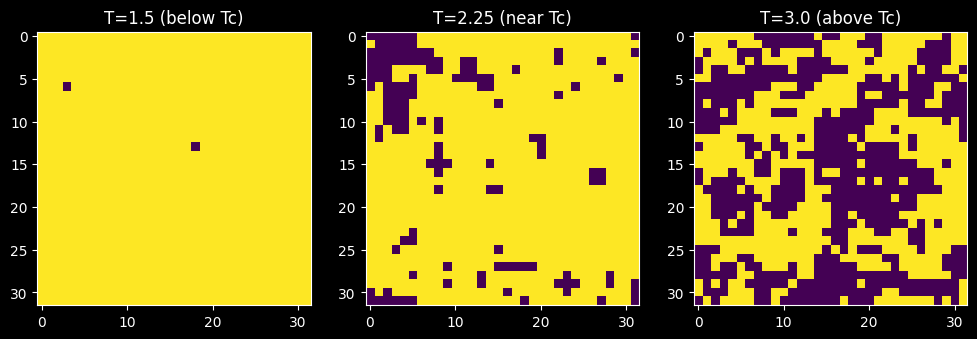

In [7]:
# Make image plots of sevaral snapshots: i) T well below Tc  ii) T near Tc, and iii) T well above Tc

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

idx_low  = np.where(Temps == Temps.min())[0][0]

# idx_mid = np.where(Temps == Tc)[0][0]
idx_mid = np.argmin(np.abs(Temps - Tc)) # Find closest since exact Tc does not exist

idx_high = np.where(Temps == Temps.max())[0][0]

axes[0].imshow(X[idx_low, :, :, 0])
axes[0].set_title(f"T={Temps.min()} (below Tc)")

axes[1].imshow(X[idx_mid, :, :, 0])
axes[1].set_title(f"T=2.25 (near Tc)")

axes[2].imshow(X[idx_high, :, :, 0])
axes[2].set_title(f"T=3.0 (above Tc)")

plt.show()


**ANS:** As Temperature Changes, the image has more upspin. 

At low temperature below Tc, The spins are mostly ordered ( only a few are purple disorder) nearly all the same color yellow. magnetized phase. 

Near Tc, there is a mix and order is starting to break down, more disorders. 

At way above Tc, there are half up and half down spins

### 1.4: Create training, validation, and test data sets

Split your data so that 70% is in the training set and 15% each are in the validation and test sets.

In [8]:
# Fill in the missing code to split the data

Nimage = len(X) # Should be 6500 from above

Ntrain = int(0.70 * Nimage)
Nvalid = int(0.15 * Nimage)
Ntest = int(0.15 * Nimage)

# shuffle the original data so that the distribution of labels will be similar across the splittings
# Note: Asked for an AI help in here prompt"how to shuffle a data set array and its lables array both in the same way so that the corrsponding labels still match
# but there is truly no pattern easy ordered pattern"

# Generate a shuffled array of indices
indices = np.arange(Nimage) # Example [0, 1, 2, 3...]
np.random.shuffle(indices)      # Shuffles the indices in-place, e.g., [1, 3, 0, 2...]

# Use the shuffled indices to reorder both arrays
shuffled_X = X[indices]
shuffled_Y = Y[indices]
shuffled_Temps = Temps[indices]


# make your splits into an (xtrain, ytrain, Ttrain), (xvalid, yvalid, Tvalid), (xtest, ytest, Ttest)

xtrain, ytrain, Ttrain = shuffled_X[:Ntrain], shuffled_Y[:Ntrain], shuffled_Temps[:Ntrain]
xvalid, yvalid, Tvalid = shuffled_X[Ntrain:Ntrain+Nvalid], shuffled_Y[Ntrain:Ntrain+Nvalid], shuffled_Temps[Ntrain:Ntrain+Nvalid]
xtest,  ytest,  Ttest  = shuffled_X[Ntrain+Nvalid:], shuffled_Y[Ntrain+Nvalid:], shuffled_Temps[Ntrain+Nvalid:]


print("(xtrain, ytrain, Ttrain), (xvalid, yvalid, Tvalid), (xtest, ytest, Ttest)")
print(f"{xtrain.shape, ytrain.shape, Ttrain.shape}, {xvalid.shape, yvalid.shape, Tvalid.shape}, {(xtest.shape, ytest.shape, Ttest.shape)}")

(xtrain, ytrain, Ttrain), (xvalid, yvalid, Tvalid), (xtest, ytest, Ttest)
((4550, 32, 32, 1), (4550,), (4550,)), ((975, 32, 32, 1), (975,), (975,)), ((975, 32, 32, 1), (975,), (975,))


1.5) Go to the section ‘Dense Neural Network’ (DNN) to see the code for defining a simple neural network.

## Task 4: Augment the training data  (Run only when instructed to in the activity guide)

For the 2D square Ising model, the system is symmetric under left->right and up->down flips.  Add these symmetry operations to triple your training data.

Ahilan's Notes: 

It can be time-consuming and frustrating making these tweaks to ANNs, as the gain in improvement is usually pretty marginal. The biggest way to improve things is to get more training data. If your system
has symmetries, one can usually then augment the dataset using the data you already have. In our case, a 2D spin configuration can be flipped vertically or horizontally, and both would also be perfectly acceptable configurations. By doing these 2 symmetry operations, we triple the size of our training dataset.

I can think about traffic signs and captcha being trained further by turning, changing the brightness and light conditions, inverting it, rotating. 



In [28]:
# Loop over training data and add the following 2 new images
# you need to append these flipped images to your training data.
# as a suggestion, you could convert your training sets back to lists and do append

# Fill in the necessary code to complete this task

# I wanted to have a code without the array to list conversion but since the 
# code used the loop, i found this the most straightforward
xtrain_list = list(xtrain)
ytrain_list = list(ytrain)


for i in range(Ntrain):

    xLeft_Right = xtrain[i][:,::-1,:]
    xUp_Down = xtrain[i][::-1, :, :]
    # add these to your xtrain set and don't forget to also add in their labels to the ytrain

    xtrain_list.append(xLeft_Right)
    xtrain_list.append(xUp_Down)
    ytrain_list.append(ytrain[i])
    ytrain_list.append(ytrain[i])


xtrain = np.array(xtrain_list)
ytrain = np.array(ytrain_list)

print("Augmented training size:", len(xtrain))

Augmented training size: 13650


With the larger Data Set, it is now 0.830, just margianlly better. 

## Task 2/3: Dense Neural Network

### Task 2: Training a Dense Neural Network

Ahilan's Notes: All neural nets start with an Input layer that specifies the shape of the input data. In our case it is a 2D image, with shape (L,L,1). After the input layer, the rest of the layers are up to you and form the neural net. The last layer is the output layer; in our case, we are doing binary classification, so it is just a single neuron (if we had more categories, then there would be more output neurons). We want its output to reflect a probability, so we will use a sigmoid function whose output goes between 0 and 1.


With our architecture defined, we wrap it up into a Keras Model, that specifies the input layers and output layers. We then compile our network for fitting, which means we must choose the type of loss function and the optimizer that we will use to solve it. We will use ‘stochastic gradient descent’ (‘SGD’) and play with its learning parameter (see the end of the activity for an exercise on SGD). There are some better solvers (e.g., Adam) that can train faster, but SGD isn’t too bad. Our loss function for a binary classification problem is binary cross-entropy, defined as
𝑙 = Σ[− 𝑦𝑘 log(𝑝𝑘) − (1−𝑦𝑘) log(1 − 𝑝𝑘)]

where 𝑦𝑘 is the label for the kth image and 𝑝𝑘 is the output from the neural net. You can see that this loss is minimized when 𝑝𝑘≈𝑦𝑘. We can also specify additional metrics to measure performance, and since we are doing classification, ‘accuracy’ is a good one to monitor (i.e., how well are we doing at predicting the correct label).


The key argument here is patience, which specifies how many epochs to allow the validation loss to increase before stopping because we are starting to overfit. We’ll go with a patience of 3 epochs.

DNNs simply consist of one layer of neurons after the other, and they are typically wide, meaning that a given layer usually has 100s to 1000s of neurons.

In Keras, this is specified with the Dense layer. Signifies Nos of Neurons

Since our input is 2D and we want to feed it into a 1D layer of neurons, we need to Flatten the input, by simply flattening it into a 1D vector. 
This is pretty straightforward


The output of a dense layer is just a linear combination of the inputs using the weights (as in our equation above in the section on neural networks). We then need to pass this to a nonlinear function, specified by the Activation layer; a popular choice is “ReLU”. 

**Another common is to “dropout” neurons during the training so that the DNN is forced to learn several ways to solve the problem. [CURIOUS]**

This is accomplished with a Dropout layer where the number represents the proportion of neurons to randomly drop at each cycle of training. This DNN has 2 wide layers, each with dropout, and ends in a single sigmoid output neuron.

### 2.1

In [29]:
#DNN

L = 32  # set the value of the image size

inputs = tf.keras.layers.Input(shape=(L,L,1))   # input layer.  Shape is the shape of the input

x = tf.keras.layers.Flatten()(inputs)      # need to flatten the 2D into 1D vector of L*L elements

x = tf.keras.layers.Dense(512)(x)              # first dense layer has 512 neurons
x = tf.keras.layers.Activation('relu')(x)      # ReLU activation
x = tf.keras.layers.Dropout(0.3)(x)            # Dropout layer - drops neurons at random at training to minimize overfitting

x = tf.keras.layers.Dense(256)(x)             # 2nd dense layer block, has 256 neurons
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Task 3.2  
# NEW 3rd dense layer block (copy of the 2nd dense layer in notebook)
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)


x = tf.keras.layers.Dense(1)(x)                   # Final output neuron (single neuron for binary classification)
outputs = tf.keras.layers.Activation('sigmoid')(x)      # sigmoid so that output is (0 -> 1)

model = tf.keras.Model(inputs = inputs, outputs = outputs)      # puts all the layers together into a Keras Model

opt = tf.keras.optimizers.SGD(learning_rate=0.001)  #Task 3.1       # choose stochastic gradient descent and learning rate 
# opt = tf.keras.optimizers.Adam()         # choose Adam - SGD with momentum. 

model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,177 (2.75 MB)

 Trainable params: 722,177 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

**Error Message: TensorFlow will use your CPU instead of GPU becase my Windows has no support. Training will be slower but ok for this activity i think**

Total Fittable/trainable Params are 656,385. All are fittable/trainable

In [30]:
# Early-stopping criterion for stopping the fitting.  
# Monitors the validation loss and stops when the number of epochs where it increases = 'patience'
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4)

### 2.2: Fit the model

Note: Bacth size is the number of image the model processes at a single time, not total size

In previous interations, I did not shuffle well (Did not put the right shuffle lables so the model saw unshuffled data) and did only 32 images by using len(x) isntead of all the images where i needed to do len(X)

In [32]:
history = model.fit(xtrain, ytrain, validation_data=[xvalid, yvalid], batch_size=32, epochs=20,callbacks=[early_stopping])

Epoch 1/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8316 - loss: 0.3723 - val_accuracy: 0.8267 - val_loss: 0.3731
Epoch 2/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8311 - loss: 0.3689 - val_accuracy: 0.8318 - val_loss: 0.3673
Epoch 3/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8285 - loss: 0.3701 - val_accuracy: 0.8308 - val_loss: 0.3628
Epoch 4/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8326 - loss: 0.3664 - val_accuracy: 0.8308 - val_loss: 0.3625


Yes — it stopped at epoch 4 instead of running all 20. That's the early stopping triggering (val_loss wasn't improving for 4 epochs in a row). 

It actually byitslef stooped at 19/20 which seems like the loss but i still did it once to be sure. 

### 2.3: Evalute the fitted model on the test set: What is the accuracy and loss?

In [33]:
model.evaluate(xtest, ytest)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8308 - loss: 0.3566


[0.3565533459186554, 0.8307692408561707]

**ANS:** Accuracy is 0.8503 and Loss is 0.3423

Task3.1: Setting learning_rate=0.001 made accurady worse, its not 0.8246

Not even tried epoch of 50, that did not make it better. 

### 2.4: Predict the probabilites of the category on the test set

Note: The prediction yields a set of probabilities 𝑝𝑘 of being below the critical temperature for each image in your test set.

In [34]:
py = model.predict(xtest)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


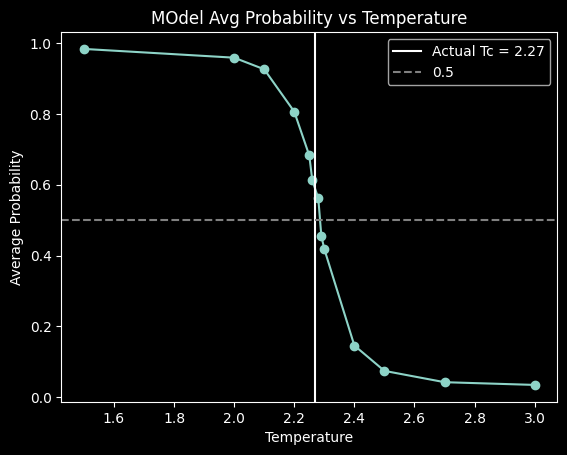

In [35]:
# Fill in code to make a plot of the average probability vs. temperature on the test set

Ttest

# 2.5
#avg_prob = [np.mean(py[Ttest == T]) for T in Ttest]

# Error: Used AI help, here Apparently Ttest must be made unique,  my previous 
# plot is showing individual probabilities, not the average probability per temperature
# Hence I must, 

unique_T = np.unique(Ttest)
avg_prob = [np.mean(py[Ttest == T]) for T in unique_T]


# 2.6
plt.plot(unique_T, avg_prob, 'o-')
#plt.plot(Ttest, avg_prob, 'o-')
plt.axvline(Tc, linestyle='-', label=f'Actual Tc = {Tc}')
plt.axhline(0.5, linestyle='--',color="grey", label='0.5')
plt.xlabel('Temperature')
plt.ylabel('Average Probability')
plt.title('MOdel Avg Probability vs Temperature')
plt.legend()
plt.show()

**ANS:** Yes, trained NN been able to discover the critical temperature (i.e., where avg pk =0.5. It clearly is very close to the actually temp just close to 2.3 instead of of 2.27

## Task 3

### 3.2: 

Code changes Made above. I predict that, because we have more neural networks, the model spends more time understanding the data and hence the accuracy must go up. 

But, no- the accuracy with 3 identical dense block actually decreased to 0.8062. 

### 3.3 
With all drop out rates at 0.1, model fits faster. And the accuracy actually increased 0.8421 

With dropout rates at 0.3, accuracy actually drops now to 0.8226. Even though the model takes more epoch and does it much slower. So having more epoch and having more taking does not really mean better accuracy. 


## Task 5: Convolutional Neural Network (CNN)

### 5.1

In [37]:
# model definitions

inputs = tf.keras.layers.Input(shape=(L,L,1))

x = tf.keras.layers.Conv2D(16, (2,2), name='C1d')(inputs)                # first convolutional layer block has 16 2x2 filters
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x)      # downsamples by 1/2 by taking max value in each 2x2 block

x = tf.keras.layers.Conv2D(16, (2,2))(x)                    # 2nd convolutional layer block has 16 2x2 filters
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Conv2D(32, (2,2))(x)                  # 3rd convolutional layer has 32 2x2 filters
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Flatten()(x)                         # flatten the extracted featureset from CNN layers # how many are there?


x = tf.keras.layers.Dense(256)(x)                       # Last block carries out the classification using a Dense layer
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.25)(x)

x = tf.keras.layers.Dense(1)(x)                         # Final output neuron as before
outputs = tf.keras.layers.Activation('sigmoid')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)

opt = tf.keras.optimizers.SGD(learning_rate=0.01)
# opt = tf.keras.optimizers.Adam()         # choose Adam - SGD with momentum. 

model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C1d (Conv2D)                    │ (None, 31, 31, 16)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,441 (302.50 KB)

 Trainable params: 77,441 (302.50 KB)

 Non-trainable params: 0 (0.00 B)

5.2

Has must lesser Parames. just 77,441 k

### 5.3: Fit model

In [38]:
history = model.fit(xtrain, ytrain, validation_data=[xvalid, yvalid], batch_size=32, epochs =50,callbacks=[early_stopping], verbose=1)

Epoch 1/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7965 - loss: 0.4269 - val_accuracy: 0.8297 - val_loss: 0.3487
Epoch 2/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8333 - loss: 0.3524 - val_accuracy: 0.8277 - val_loss: 0.3459
Epoch 3/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8333 - loss: 0.3450 - val_accuracy: 0.8287 - val_loss: 0.3391
Epoch 4/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8385 - loss: 0.3399 - val_accuracy: 0.8277 - val_loss: 0.3307
Epoch 5/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8363 - loss: 0.3366 - val_accuracy: 0.8287 - val_loss: 0.3299
Epoch 6/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8361 - loss: 0.3344 - val_accuracy: 0.8338 - val_loss: 0.3280
Epoch 7/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8357 - loss: 0.3336 - val_accuracy: 0.8328 - val_loss: 0.3312
Epoch 8/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8369 - loss: 0.3303 - val_accuracy

In [39]:
model.evaluate(xtest, ytest)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8513 - loss: 0.3210


[0.3210200071334839, 0.8512820601463318]

In [40]:
py = model.predict(xtest)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


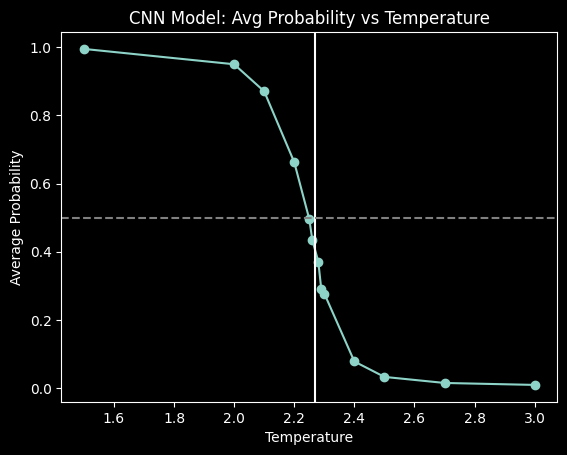

In [41]:
# make plot of average probability vs. temperature for test set

unique_T = np.unique(Ttest)
avg_prob = [np.mean(py[Ttest == T]) for T in unique_T]

plt.plot(unique_T, avg_prob, 'o-')
plt.axvline(Tc, linestyle='-', label=f'Actual Tc = {Tc}')
plt.axhline(0.5, linestyle='--', color='grey', label='0.5')
plt.xlabel('Temperature')
plt.ylabel('Average Probability')
plt.title('CNN Model: Avg Probability vs Temperature')
plt.show()

Yes, it has an accuracy of 0.8513 thats, with lesser number of parameters. and the plot looks accurate as well. 

## Task 6: Predicting on novel data

Use the fitted CNN (or DNN if you want) to make predictions on data from configurations generated by a unknown model that displays a phase transition.  Now we don't have any $Y$-labels, as we don't know the transition temperature.

In [48]:
# Task 6: Read in nonIsing data and predict


X_novel = []   # the 2D image files
Temps_novel = []   # Temperature that each image was taken at

nonIsing_path = "D:/Documents/SFU/Phys395-ComputationalPhysics/computational-physics/Week9/nonIsing/nonIsing"

for folder in os.listdir(nonIsing_path):
    T = float(folder.strip("T")) # To remove that T in the start


    for f in os.listdir("nonIsing/nonIsing/" + folder):
        if f.startswith("img") and f.endswith(".dat"): # skip config files like "in.dat"
            x = np.genfromtxt("nonIsing/nonIsing/" + folder + "//" + f)

            L = x.shape[0]
            x = np.reshape(x, (L,L,1))



            X_novel.append(x)
            Temps_novel.append(T)



# convert X_novel, Temps_novel into arrays
X_novel = np.array(X_novel)
Temps_novel = np.array(Temps_novel)
# print out shape of X_novel
print(f"X_novel.shape = {X_novel.shape}")

ValueError: cannot reshape array of size 12 into shape (32,32,1)

In [47]:
# 6.2
py_novel = model.predict(X_novel)

unique_T_novel = np.unique(Temps_novel)
avg_prob_novel = [np.mean(py_novel[Temps_novel == T]) for T in unique_T_novel]

plt.plot(unique_T_novel, avg_prob_novel, 'o-')
plt.axhline(0.5, linestyle='--', color='grey', label='0.5')
plt.xlabel('Temperature')
plt.ylabel('Average Probability')
plt.title('nonIsing: Avg Probability vs Temperature')
plt.legend()
plt.show()

c:\Users\ahila\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


ValueError: math domain error